# demiwtg 下载质量分析（zh 补齐 296k + EN 平行链）

**回答的问题**：两条下载链（中文补齐链 + EN 平行链）现在下来的图，质量结构长什么样、靠什么源、有哪些要修的。

**数据源**（全部现算，不落盘）：
- `datasets/demiwtg/meta/metadata.jsonl` —— 中文链清单（含 08-29 前老链路的标注行）
- `datasets/demiwtg/meta/metadata_en.jsonl` —— EN 平行链清单（纯下载）
- `datasets/demiwtg/meta/{taxonomy,taxonomy_en,instances,instances_en}.json` —— 域归属与全量名册
- `state/collect/source_health_v2_en.json` —— EN 源健康账本（节流/停用/计数）
- `state/collect/branch_routes_en.json` —— EN 分支路由缓存（LLM 选源）

**口径注意（必读）**：
1. 2026-08-29 拍板：两条链均 `--no-annotate`（caption/quality/identity 暂缓），所以**新行的质量字段为 null 属预期**，本册用分辨率/体积/源结构等代理指标评估下载质量；VLM 打分视角只在「旧标注行存量」一节看（第 5 节）。
2. 补齐阶段的起点按 08-29（UTC）切分 `fetched_at`。
3. 内容寻址天然去重：同一 sha 多行=多实例共享同图，合法。

In [1]:
import json, os, time, random, hashlib, html as _html
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from IPython.display import display, HTML

plt.rcParams['font.family'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
random.seed(42); np.random.seed(42)
pd.set_option('display.width', 200)

REPO      = Path('/tank/demiwtg')
META_DIR  = REPO / 'datasets/demiwtg/meta'
LAKE      = REPO / 'datasets/demiwtg'
BLOBS     = LAKE / 'blobs'
META_ZH   = META_DIR / 'metadata.jsonl'
META_EN   = META_DIR / 'metadata_en.jsonl'
TAX_ZH    = META_DIR / 'taxonomy.json'
TAX_EN    = META_DIR / 'taxonomy_en.json'
INST_ZH   = META_DIR / 'instances.json'
INST_EN   = META_DIR / 'instances_en.json'
HEALTH_EN = REPO / 'state/collect/source_health_v2_en.json'
ROUTES_EN = REPO / 'state/collect/branch_routes_en.json'

con = duckdb.connect()
con.execute('SET threads=8')

# 一次性物化成表（1.4GB JSON 只扫一遍，后续 cell 免重扫）
for tbl, p in [('zh', META_ZH), ('en', META_EN)]:
    con.execute(f"""
    CREATE OR REPLACE TABLE {tbl} AS
    SELECT source, sha256, ext, mime, width, height, size_bytes, license, author,
           identity, quality, kb_match, fetched_at, path, landing_url, instances
    FROM read_json_auto('{p}')""")

for tbl in ['zh', 'en']:
    n, u, t0, t1 = con.execute(
        f'SELECT count(*), count(DISTINCT sha256), min(fetched_at), max(fetched_at) FROM {tbl}').fetchone()
    print(f'{tbl}: {n:,} 行 / 唯一 sha {u:,} / 时间 {datetime.fromtimestamp(t0):%m-%d %H:%M} ~ {datetime.fromtimestamp(t1):%m-%d %H:%M}')
    nw = con.execute(f'SELECT count(*) FROM {tbl} WHERE width IS NULL').fetchone()[0]
    ann = con.execute(f'SELECT count(*) FROM {tbl} WHERE quality IS NOT NULL').fetchone()[0]
    print(f'    width 为 null: {nw:,} 行；带 VLM 标注（quality 非空）: {ann:,} 行（{ann/n:.1%}）')

zh: 1,485,654 行 / 唯一 sha 1,169,954 / 时间 08-12 17:23 ~ 08-30 08:08
    width 为 null: 0 行；带 VLM 标注（quality 非空）: 516,810 行（34.8%）
en: 31,450 行 / 唯一 sha 16,437 / 时间 08-29 09:04 ~ 08-30 08:08
    width 为 null: 0 行；带 VLM 标注（quality 非空）: 0 行（0.0%）


## 1. 覆盖进度（对照 instances 名册 + 域归属）

- 覆盖口径：清单里出现过至少 1 张图的实例（本阶段 `--min-quality 0`，不带质量门）。
- 域归属从树现场聚合（`path` 第二段 = 域；跨域多挂实例在每个域各计 1）。

In [2]:
def inst_domain_map(tax_path):
    tree = json.load(open(tax_path))['tree']
    m = {}
    def walk(node):
        segs = node['path'].split(' / ')
        dom = segs[1] if len(segs) >= 2 else '(root)'
        for name in node.get('instances') or []:
            m.setdefault(name, set()).add(dom)
        for ch in node.get('children') or []:
            walk(ch)
    walk(tree)
    return m

dom_zh = inst_domain_map(TAX_ZH)
dom_en = inst_domain_map(TAX_EN)
total_zh = len(json.load(open(INST_ZH))['instances'])
total_en = len(json.load(open(INST_EN))['instances'])

cov_zh = set(r[0] for r in con.execute('SELECT DISTINCT unnest(instances) FROM zh').fetchall())
cov_en = set(r[0] for r in con.execute('SELECT DISTINCT unnest(instances) FROM en').fetchall())
print(f'zh 覆盖 {len(cov_zh):,} / {total_zh:,}（{len(cov_zh)/total_zh:.1%}），未覆盖 {total_zh-len(cov_zh):,}')
print(f'en 覆盖 {len(cov_en):,} / {total_en:,}（{len(cov_en)/total_en:.1%}），未覆盖 {total_en-len(cov_en):,}')

def domain_cover(dom_map, cov):
    rec = {}
    for name, doms in dom_map.items():
        for d in doms:
            t, c = rec.get(d, (0, 0))
            rec[d] = (t + 1, c + (1 if name in cov else 0))
    return pd.DataFrame([(d, t, c, c / t) for d, (t, c) in rec.items()],
                        columns=['domain', 'inst', 'covered', 'pct']).sort_values('pct').reset_index(drop=True)

dc_zh = domain_cover(dom_zh, cov_zh)
dc_en = domain_cover(dom_en, cov_en)
print('\nzh 各域覆盖（缺口最大在前）：')
print(dc_zh.assign(pct=(dc_zh.pct*100).round(1)).to_string(index=False))
print('\nen 各域覆盖（缺口最大前 10）：')
print(dc_en.head(10).assign(pct=(dc_en.pct*100).round(1)).to_string(index=False))

for tbl, label in [('zh', 'zh'), ('en', 'en')]:
    ipc = con.execute(f'SELECT i, count(*) n FROM (SELECT unnest(instances) AS i FROM {tbl}) GROUP BY 1').df()
    print(f'\n{label} 每实例图数：median={ipc.n.median():.0f} p90={ipc.n.quantile(.9):.0f} '
          f'max={ipc.n.max()}；仅 1 张的实例占 {(ipc.n==1).mean():.1%}')

zh 覆盖 170,102 / 296,010（57.5%），未覆盖 125,908
en 覆盖 17,615 / 382,341（4.6%），未覆盖 364,726

zh 各域覆盖（缺口最大在前）：
    domain  inst  covered   pct
     宗教与信仰    14        0   0.0
      行为动作 19599      752   3.8
   文字与信息图形  8520      400   4.7
政治、法律与社会制度   416       34   8.2
   时间数量与度量  3995      402  10.1
      自然景观  8366      848  10.1
     节日与符号  3680      391  10.6
     属性与状态  8115      970  12.0
      交通工具  6671      967  14.5
        声音  6419      974  15.2
     材料与物质  4338      664  15.3
        食物 18042     2886  16.0
     医学与健康   423       74  17.5
     地理与地点  1106      228  20.6
        场景 10553     2728  25.9
     人物与人体 18229     5403  29.6
 组织机构与社会事件  7745     2325  30.0
  民族、语言与文化   258      126  48.8
   文化艺术与媒介 19300    10530  54.6
     知识与学科  5285     3299  62.4
   建筑与基础设施 29960    19315  64.5
        植物 22790    20426  89.6
     历史与时代  1399     1269  90.7
     品牌与产品  7870     7695  97.8
     体育与游戏  2019     2000  99.1
        动物 21954    21946 100.0
      人造物体 72642    72616 100.0
  


zh 每实例图数：median=8 p90=10 max=146；仅 1 张的实例占 0.0%

en 每实例图数：median=2 p90=2 max=6；仅 1 张的实例占 29.1%


## 2. zh 分源画像（分辨率 / 体积 / 许可 / 阶段占比）

代理质量指标：短边分位数、小图率（<256 缩略图级 / <512 / <768 基准门）。
`fill_share` = 该源行数中 08-29 补齐阶段（`--no-annotate` 起）的占比，用于区分「历史源」与「当前在打的源」。

In [3]:
FILL_SINCE = datetime(2026, 8, 29, tzinfo=timezone.utc).timestamp()   # 补齐阶段起点（08-29 拍板）

prof = con.execute(f"""
SELECT source, count(*) AS rows,
       quantile_cont(least(width, height), 0.1) AS p10,
       quantile_cont(least(width, height), 0.5) AS p50,
       quantile_cont(least(width, height), 0.9) AS p90,
       avg(CASE WHEN least(width, height) < 256 THEN 1.0 WHEN least(width,height) IS NULL THEN NULL ELSE 0 END) AS r_lt256,
       avg(CASE WHEN least(width, height) < 512 THEN 1.0 WHEN least(width,height) IS NULL THEN NULL ELSE 0 END) AS r_lt512,
       avg(CASE WHEN least(width, height) < 768 THEN 1.0 WHEN least(width,height) IS NULL THEN NULL ELSE 0 END) AS r_lt768,
       median(size_bytes) / 1024 AS kb50,
       avg(CASE WHEN license IS NOT NULL AND license != '' THEN 1.0 ELSE 0 END) AS lic,
       avg(CASE WHEN author IS NOT NULL THEN 1.0 ELSE 0 END) AS auth,
       avg(CASE WHEN fetched_at >= {FILL_SINCE} THEN 1.0 ELSE 0 END) AS fill_share
FROM zh GROUP BY 1 ORDER BY rows DESC""").df()
prof.insert(1, 'share', (prof['rows'] / prof['rows'].sum()))
display(prof.round(3))

ph = con.execute(f"""SELECT source, CASE WHEN fetched_at >= {FILL_SINCE} THEN 'fill(08-29+)' ELSE 'history' END AS phase, count(*) n
FROM zh GROUP BY 1, 2""").df().pivot(index='source', columns='phase', values='n').fillna(0).astype(int)
print('\n阶段 × 源（行数）：')
print(ph.to_string())

share = con.execute("""
SELECT count(*) AS multi_inst_sha FROM (
  SELECT sha256 FROM (SELECT sha256, unnest(instances) i FROM zh) GROUP BY sha256 HAVING count(DISTINCT i) > 1)""").fetchone()[0]
n_uniq = con.execute('SELECT count(DISTINCT sha256) FROM zh').fetchone()[0]
print(f'\n跨实例共享图：{share:,} 个 sha 被多个实例引用（占唯一 sha {share/n_uniq:.1%}，内容寻址去重正常）')

,source,share,rows,p10,p50,p90,r_lt256,r_lt512,r_lt768,kb50,lic,auth,fill_share
0,bing_images,0.223,331456,350.0,683.0,1280.0,0.026,0.280,0.586,153.057,0.000,0.000,0.361
1,toutiao,0.207,307177,200.0,264.0,720.0,0.474,0.739,0.917,26.727,0.002,0.000,0.429
2,baidu,0.201,299167,500.0,500.0,800.0,0.003,0.865,0.881,26.730,0.012,0.000,0.489
3,so360,0.192,285292,254.0,466.0,1024.0,0.102,0.560,0.739,65.940,0.000,0.000,0.484
4,huaban_api,0.134,199452,450.0,790.0,1728.0,0.017,0.140,0.462,215.969,0.047,0.000,0.424
5,pixiv,0.009,12953,640.0,1200.0,2628.6,0.005,0.046,0.165,785.606,0.000,1.000,0.000
6,wikimedia,0.008,12332,787.1,2081.0,3456.0,0.015,0.057,0.087,1926.479,1.000,0.964,0.000
7,yandex_images,0.007,10729,360.0,731.0,1613.0,0.045,0.276,0.551,111.257,0.000,0.000,0.000
8,inaturalist,0.007,10223,1000.0,1500.0,1542.0,0.000,0.000,0.000,1150.611,1.000,0.978,0.000
9,wikimedia_zh,0.005,7182,400.0,1629.0,3345.5,0.041,0.168,0.238,1172.772,1.000,0.956,0.128



阶段 × 源（行数）：
phase          fill(08-29+)  history
source                              
anilist                   0     1436
baidu                146351   152816
bing                      0      844
bing_images          119795   211661
deviantart                0     1727
fandom                    0     1054
huaban_api            84569   114883
inaturalist               0    10223
konachan                  0       34
mal                       0     3218
pixiv                     0    12953
safebooru                 0     1266
so360                138206   147086
toutiao              131783   175394
wikimedia                 0    12332
wikimedia_zh            921     6261
yandere                   0      112
yandex_images             0    10729



跨实例共享图：104,327 个 sha 被多个实例引用（占唯一 sha 8.9%，内容寻址去重正常）


## 3. 分辨率 / 体积 / 格式分布（zh 补齐阶段 vs zh 历史 vs EN）

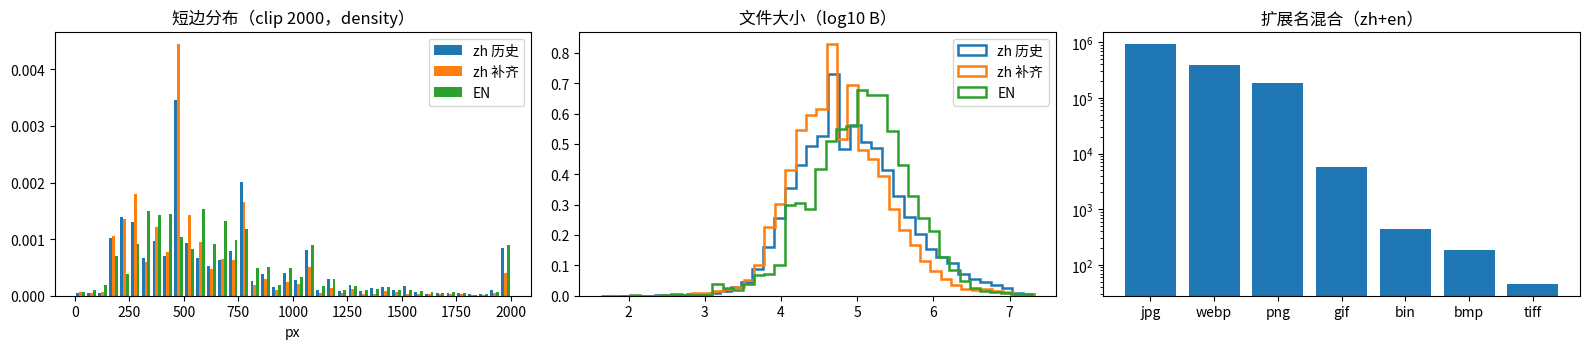

短边中位数： {'zh 历史': 520, 'zh 补齐': 500, 'EN': 600}
体积中位数 KB： {'zh 历史': 72, 'zh 补齐': 51, 'EN': 115}


In [4]:
zh_fill = con.execute(f'SELECT least(width,height) v, size_bytes FROM zh WHERE fetched_at >= {FILL_SINCE}').df()
zh_hist = con.execute(f'SELECT least(width,height) v, size_bytes FROM zh WHERE fetched_at < {FILL_SINCE}').df()
en_v    = con.execute('SELECT least(width,height) v, size_bytes FROM en').df()

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
axes[0].hist([zh_hist.v.clip(0, 2000), zh_fill.v.clip(0, 2000), en_v.v.clip(0, 2000)],
             bins=40, density=True, label=['zh 历史', 'zh 补齐', 'EN'])
axes[0].set_title('短边分布（clip 2000，density）'); axes[0].legend(); axes[0].set_xlabel('px')
for s, df in [('zh 历史', zh_hist), ('zh 补齐', zh_fill), ('EN', en_v)]:
    axes[1].hist(np.log10(df.size_bytes), bins=40, density=True, histtype='step', linewidth=1.8, label=s)
axes[1].set_title('文件大小（log10 B）'); axes[1].legend()
ext = con.execute("""SELECT ext, count(*) n FROM (
  SELECT ext FROM zh UNION ALL SELECT ext FROM en) GROUP BY 1 ORDER BY n DESC LIMIT 8""").df()
axes[2].bar(ext.ext, ext.n); axes[2].set_title('扩展名混合（zh+en）'); axes[2].set_yscale('log')
plt.tight_layout(); plt.show()

print('短边中位数：', {s: round(df.v.median()) for s, df in [('zh 历史', zh_hist), ('zh 补齐', zh_fill), ('EN', en_v)]})
print('体积中位数 KB：', {s: round(df.size_bytes.median()/1024) for s, df in [('zh 历史', zh_hist), ('zh 补齐', zh_fill), ('EN', en_v)]})

## 4. 旧标注行的 VLM 质量存量（08-29 前老链路）

> **这只代表老链路打的标**。补齐阶段 `--no-annotate` 是拍板（下载优先），新行待全量下载完成后的补标链（op_backfill）再评。

,source,n,q_mean,q50,id_rate,q8_rate
0,bing_images,139175,7.681,8.8,0.662,0.711
1,toutiao,101545,3.433,1.6,0.221,0.199
2,baidu,77413,7.947,8.8,0.680,0.743
3,so360,73180,7.532,8.6,0.635,0.681
4,huaban_api,63937,6.418,7.6,0.422,0.483
5,pixiv,12667,4.431,5.0,0.071,0.146
6,wikimedia,12306,4.391,4.4,0.165,0.246
7,yandex_images,10726,6.743,8.0,0.401,0.520
8,inaturalist,10223,1.460,1.4,0.001,0.001
9,wikimedia_zh,5949,4.720,5.0,0.221,0.293


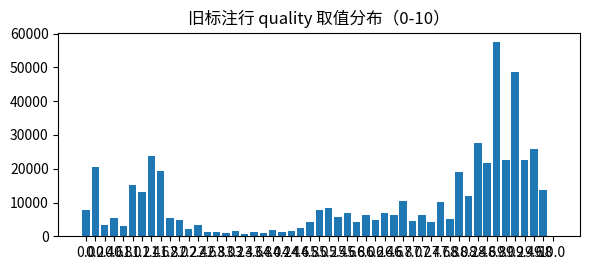

In [5]:
ann = con.execute("""
SELECT source, count(*) n, avg(quality) q_mean, quantile_cont(quality, 0.5) q50,
       avg(CASE WHEN identity THEN 1.0 ELSE 0 END) id_rate,
       avg(CASE WHEN quality >= 8 THEN 1.0 ELSE 0 END) q8_rate
FROM zh WHERE quality IS NOT NULL GROUP BY 1 ORDER BY n DESC""").df()
display(ann.round(3))

qv = con.execute('SELECT quality, count(*) n FROM zh WHERE quality IS NOT NULL GROUP BY 1 ORDER BY 1').df()
plt.figure(figsize=(6, 2.8))
plt.bar(qv.quality.astype(str), qv.n)
plt.title('旧标注行 quality 取值分布（0-10）'); plt.tight_layout(); plt.show()

## 5. EN 链：分源画像 + 分支路由缓存

关注点：bing 单源依赖度（交接快照 94%）、路由缓存推进（封顶 2,719 主分支）、路由选了但账本打不到的源。

In [6]:
prof_en = con.execute("""
SELECT source, count(*) AS rows,
       quantile_cont(least(width, height), 0.1) AS p10,
       quantile_cont(least(width, height), 0.5) AS p50,
       quantile_cont(least(width, height), 0.9) AS p90,
       avg(CASE WHEN least(width, height) < 512 THEN 1.0 WHEN least(width,height) IS NULL THEN NULL ELSE 0 END) AS r_lt512,
       avg(CASE WHEN least(width, height) < 768 THEN 1.0 WHEN least(width,height) IS NULL THEN NULL ELSE 0 END) AS r_lt768,
       median(size_bytes) / 1024 AS kb50
FROM en GROUP BY 1 ORDER BY rows DESC""").df()
prof_en.insert(1, 'share', prof_en['rows'] / prof_en['rows'].sum())
display(prof_en.round(3))
print(f"bing_images 行占比：{(prof_en.loc[prof_en.source=='bing_images','share'].iloc[0] if (prof_en.source=='bing_images').any() else 0):.1%}")

routes = json.load(open(ROUTES_EN))
rl = [(p, v['sources']) for p, v in routes.items()]
src_freq = Counter(s for _, ss in rl for s in ss)
nsrc_dist = Counter(len(ss) for _, ss in rl)
print(f'\n分支路由缓存：{len(rl):,} / 2,719 主分支（{len(rl)/2719:.0%}）')
print('路由源频次：', dict(src_freq.most_common()))
print('每分支路由源数分布：', dict(sorted(nsrc_dist.items())))

,source,share,rows,p10,p50,p90,r_lt512,r_lt768,kb50
0,bing_images,0.941,29582,299.0,593.0,1200.0,0.405,0.683,114.624
1,wikimedia,0.031,984,300.0,995.0,3094.4,0.299,0.414,403.419
2,deviantart,0.028,879,487.8,730.0,894.0,0.115,0.638,108.393
3,mal,0.000,5,225.0,225.0,256.2,1.000,1.000,23.865


bing_images 行占比：94.1%

分支路由缓存：1,738 / 2,719 主分支（64%）
路由源频次： {'bing_images': 1738, 'wikimedia': 1505, 'yandex_images': 1446, 'pixiv': 25, 'deviantart': 6, 'anilist': 2, 'mal': 2}
每分支路由源数分布： {1: 10, 2: 483, 3: 1232, 4: 13}


## 6. EN 源健康账本 + 双链下载速率时序

,source,throttle,state,search_call,hit_rate,dl_call,dl_ok_rate,http403,http429,http5xx
0,bing_images,0.25,active,18381,1.000,33873,0.865,2141,21,623
1,wikimedia,0.25,active,17067,0.945,31673,0.031,0,122334,0
2,yandex_images,1.00,DISABLED,3389,0.000,0,NaN,0,0,0
3,deviantart,1.00,active,477,0.899,838,1.000,1158,0,0
4,mal,NaN,active,2,1.000,3,1.000,0,0,0
5,pixiv,0.25,active,0,NaN,0,NaN,2083,0,0


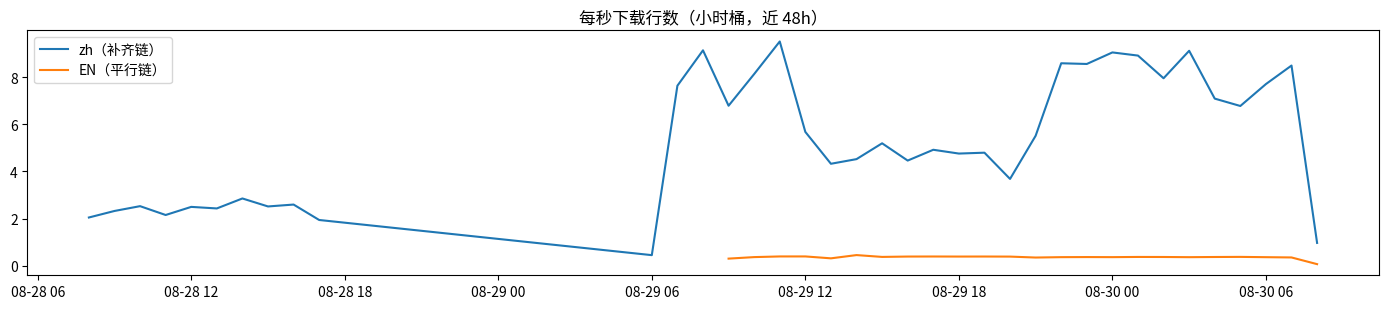

zh：近 1h 30,173 行（8.38/s），近 6h 168,859 行（7.82/s）
en：近 1h 1,359 行（0.38/s），近 6h 8,100 行（0.38/s）


In [7]:
h = json.load(open(HEALTH_EN))
mult, dis, tot = h.get('mult', {}), h.get('disabled_until', {}), h.get('totals', {})
now = time.time()
rows = []
for s, t in tot.items():
    sc, sh_ = t.get('search_call', 0), t.get('search_hit', 0)
    dc, do = t.get('dl_call', 0), t.get('dl_ok', 0)
    rows.append(dict(source=s, throttle=mult.get(s),
                     state='DISABLED' if dis.get(s, 0) > now else 'active',
                     search_call=sc, hit_rate=round(sh_ / sc, 3) if sc else None,
                     dl_call=dc, dl_ok_rate=round(do / dc, 3) if dc else None,
                     http403=t.get('403', 0), http429=t.get('429', 0), http5xx=t.get('5xx', 0)))
display(pd.DataFrame(rows).sort_values('search_call', ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(14, 3.2))
for tbl, label, c in [('zh', 'zh（补齐链）', 'tab:blue'), ('en', 'EN（平行链）', 'tab:orange')]:
    mx = con.execute(f'SELECT max(fetched_at) FROM {tbl}').fetchone()[0]
    hr = con.execute(f"""SELECT floor(fetched_at/3600)*3600 AS h, count(*) n FROM {tbl}
        WHERE fetched_at >= {mx} - 48*3600 GROUP BY 1 ORDER BY 1""").df()
    ax.plot(pd.to_datetime(hr.h, unit='s'), hr.n / 3600, label=label, color=c)
ax.set_title('每秒下载行数（小时桶，近 48h）'); ax.legend(); plt.tight_layout(); plt.show()

for tbl in ['zh', 'en']:
    mx, t1h = con.execute(f'SELECT max(fetched_at), max(fetched_at)-3600 FROM {tbl}').fetchone()
    r1h, r6h = con.execute(f"""SELECT count(*) FILTER (WHERE fetched_at > {t1h}),
        count(*) FILTER (WHERE fetched_at > {mx}-6*3600) FROM {tbl}""").fetchone()
    print(f'{tbl}：近 1h {r1h:,} 行（{r1h/3600:.2f}/s），近 6h {r6h:,} 行（{r6h/6/3600:.2f}/s）')

## 7. 抽样看图（源画像人工审阅）

**重点用例**：EN bing 拼音/译名查询的歧义图风险审阅（交接下一步 ①）。改 `LANG_SEL` / `SOURCES` / `EXTRA` 换切片，例如 `EXTRA = "least(width,height) < 300"` 专看小图。

In [8]:
LANG_SEL = 'en'      # ← 'zh' / 'en'
SOURCES  = None     # ← None=该链 Top4 源；或 ['bing_images', 'wikimedia']
N_PER    = 8        # 每源抽几张
EXTRA    = '1=1'    # ← 附加过滤（duckdb 语法），如 "least(width,height) < 300"

src_top = con.execute(f'SELECT source, count(*) n FROM {LANG_SEL} GROUP BY 1 ORDER BY n DESC').df()
srcs = SOURCES or src_top.source.head(4).tolist()
in_list = ','.join(f"'{s}'" for s in srcs)
rows = con.execute(f"""SELECT source, unnest(instances) inst, width, height, size_bytes, path, landing_url
    FROM {LANG_SEL} WHERE source IN ({in_list}) AND ({EXTRA})
    ORDER BY random() LIMIT {N_PER * len(srcs)}""").df()

def gallery(df, title):
    cards = []
    for r in df.itertuples():
        p = LAKE / r.path
        ok = p.is_file()
        cards.append(f'''<div style="width:232px;margin:2px">
          <img src="file://{p}" style="max-width:224px;max-height:200px;object-fit:contain;{'filter:grayscale(1);opacity:.25' if not ok else ''}">
          <div style="font-size:12px">{_html.escape(str(r.inst))} · {r.width}×{r.height} · {int(r.size_bytes)//1024}KB{'' if ok else ' · 文件缺失'}</div>
          <div style="font-size:11px;color:#888">{r.source} · <a href="{r.landing_url}">landing</a></div></div>''')
    display(HTML(f'<div style="font-weight:600;margin:6px 0">{title}</div>'
                 + '<div style="display:flex;flex-wrap:wrap;align-items:flex-start">' + ''.join(cards) + '</div>'))

for s in srcs:
    sub = rows[rows.source == s]
    if len(sub):
        gallery(sub, f'{s}（{int(src_top.set_index("source").n.get(s, 0)):,} 行）')

## 8. 按域抽样看图

域名单见第 1 节的覆盖表（zh 中文域名 / en 英文域名）。同时报该域未覆盖实例数，辅助判断「图质差 vs 还没采到」。

In [9]:
LANG_SEL = 'zh'        # ← 'zh' / 'en'
DOMAIN   = '人造物体'    # ← 改这里：目标域（zh 用中文域名，en 用英文域名，见第 1 节覆盖表）
N        = 12

dm, cov = (dom_zh, cov_zh) if LANG_SEL == 'zh' else (dom_en, cov_en)
names = {n for n, ds in dm.items() if DOMAIN in ds}
assert names, f'域「{DOMAIN}」不在 {LANG_SEL} 树的 29 域里；可用域见第 1 节覆盖表'
covered = names & cov
print(f'域「{DOMAIN}」：挂载实例 {len(names):,}，已覆盖 {len(covered):,}（{len(covered)/max(len(names),1):.1%}），未覆盖 {len(names)-len(covered):,}')
assert covered, '该域还没有任何已覆盖实例'

import random as _rnd
sel = _rnd.sample(sorted(covered), min(N, len(covered)))
cond = ' OR '.join(f"list_contains(instances, '{n.replace(chr(39), chr(39)*2)}')" for n in sel)
rows = con.execute(f"""SELECT source, unnest(instances) inst, width, height, size_bytes, path, landing_url
    FROM {LANG_SEL} WHERE {cond} ORDER BY random()""").df()
gallery(rows, f'{DOMAIN} 随机抽样')

域「人造物体」：挂载实例 72,642，已覆盖 72,616（100.0%），未覆盖 26


## 9. blob 完整性抽检（文件在位 + sha256 与文件名一致）

In [10]:
K = 300   # 抽检条数（zh+en 合并抽样）
samp = con.execute(f"""SELECT path FROM (
  SELECT path FROM zh UNION ALL SELECT path FROM en) USING SAMPLE {K}""").df()
bad = []
for p in samp.itertuples():
    fp = LAKE / p.path
    if not fp.is_file():
        bad.append((p.path, 'missing')); continue
    if hashlib.sha256(fp.read_bytes()).hexdigest() != fp.stem:
        bad.append((p.path, 'sha-mismatch'))
print(f'抽检 {len(samp)} 个 blob：异常 {len(bad)}')
for b in bad[:10]:
    print('  ', b)
nblobs = sum(len(fs) for _, _, fs in os.walk(BLOBS))
print(f'blobs 总文件数：{nblobs:,}')

抽检 300 个 blob：异常 0


blobs 总文件数：1,462,578


## 10. 下载重复与净新增 + 活链尾行

sink 去重键 = (sha256, instance)，同键双写为零；所以「同 sha 多行」= **跨实例共享**（合法多挂，字节只存一份，
成本是检索槽位/带宽）。要盯的浪费是**撞湖**（图字节已在湖里，为挂新实例又下了一遍）和净新增效率。
EN 撞 zh 湖同理：共 blobs 内容寻址天然去重，撞=带宽浪费而非双存储。

In [11]:
import re
LOG_ZH = REPO / 'logs/collect_dl_fill296k_20260829.log'   # ← zh 补齐链日志（只读尾行）
LOG_EN = REPO / 'logs/collect_dl_en_pilot_20260829.log'   # ← EN 链日志

r_z, s_z, hit_z = con.execute(f"""
WITH b AS (SELECT sha256 FROM zh WHERE fetched_at >= {FILL_SINCE}),
     p AS (SELECT DISTINCT sha256 FROM zh WHERE fetched_at < {FILL_SINCE})
SELECT (SELECT count(*) FROM b), (SELECT count(DISTINCT sha256) FROM b),
       (SELECT count(DISTINCT b.sha256) FROM b JOIN p USING (sha256))""").fetchone()
print(f"zh 补齐阶段：{r_z:,} 行 / 唯一 sha {s_z:,} | 同 sha 跨实例行 {r_z-s_z:,}（{(r_z-s_z)/r_z:.1%}）"
      f" | 撞存量湖 {hit_z:,} sha（{hit_z/s_z:.1%}） | 净新增字节图 {s_z-hit_z:,}")

r_e, s_e = con.execute('SELECT count(*), count(DISTINCT sha256) FROM en').fetchone()
hit_e = con.execute('SELECT count(*) FROM (SELECT DISTINCT sha256 FROM en) d JOIN (SELECT DISTINCT sha256 FROM zh) z USING (sha256)').fetchone()[0]
print(f"EN：{r_e:,} 行 / 唯一 sha {s_e:,} | 同 sha 跨实例行 {r_e-s_e:,}（{(r_e-s_e)/r_e:.1%}）"
      f" | 撞 zh 湖 {hit_e:,} sha（{hit_e/s_e:.1%}） | 净新增字节图 {s_e-hit_e:,}")

gate = con.execute("""SELECT count(*), avg(CASE WHEN quality>=9 AND identity AND least(width,height)>=768 THEN 1.0 ELSE 0 END)
    FROM zh WHERE quality IS NOT NULL""").fetchone()
print(f"[参照] 老链路已标注行过 t2i 抽样门（quality≥9 & identity & 短边≥768）：{gate[1]:.1%}")

def tail_progress(p):
    if not p.exists(): return '(日志不存在)'
    with open(p, 'rb') as f:
        f.seek(0, 2); f.seek(max(0, f.tell()-300000)); s = f.read().decode('utf-8', 'ignore')
    m = re.findall(r'\[进度\] (\d+)/(\d+) （([\d.]+) 实例/s） 落盘=(\d+) 下载=(\d+) 完全重复跳过=(\d+)', s)
    return f'片内 {m[-1][0]}/{m[-1][1]} 实例（{m[-1][2]} 实例/s） 落盘 {m[-1][3]} / 下载 {m[-1][4]} / 同键跳过 {m[-1][5]}' if m else '(无进度行)'
print('zh 活链尾行:', tail_progress(LOG_ZH))
print('en 活链尾行:', tail_progress(LOG_EN))

zh 补齐阶段：621,625 行 / 唯一 sha 439,679 | 同 sha 跨实例行 181,946（29.3%） | 撞存量湖 22,633 sha（5.1%） | 净新增字节图 417,046
EN：31,450 行 / 唯一 sha 16,437 | 同 sha 跨实例行 15,013（47.7%） | 撞 zh 湖 2,879 sha（17.5%） | 净新增字节图 13,558
[参照] 老链路已标注行过 t2i 抽样门（quality≥9 & identity & 短边≥768）：9.3%
zh 活链尾行: 片内 10900/136779 实例（1.1 实例/s） 落盘 85971 / 下载 85998 / 同键跳过 26
en 活链尾行: 片内 180/1000 实例（0.8 实例/s） 落盘 201 / 下载 202 / 同键跳过 0


## 11. 读法速查

- **总览**：第 1 节覆盖进度 + 第 6 节速率/账本 → 判断「还要多久、卡在哪个源」。
- **下载质量**：第 2/3 节（分辨率/体积/小图率代理）+ 第 7 节人眼审阅（bing 歧义重点）。
- **VLM 质量门**：只有第 4 节老链路存量可看；补齐/EN 新行等补标链（op_backfill）跑完再评。
- **浪费与净增**：第 10 节同 sha 跨实例行 / 撞湖率 / 净新增字节图 + 活链尾行实时进度。
- **行动入口**（对照交接手册）：EN 源调优（yandex 移出注册表 / wikimedia 节流放宽）→ 第 5/6 节给依据；zh 收尾后 adopt 源策略 → 第 2 节 `fill_share` 看当前实际在用的源。
- 所有参数在各 cell 头部，直接改了重跑。